# Module 2 — Colorectal Cancer HIPEC Agents: Serious Outcomes

**Prerequisite:** Run `01_hipec_explore.ipynb` first to create the `oxaliplatin_analysis` and `mitomycin_analysis` tables.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

db_path = r"C:\Users\palla\OneDrive\Documents\Coding Projects\FDA_FAERS\database\faers.db"
conn = sqlite3.connect(db_path)

## Step 1: Overall Outcome Distribution

How are serious outcomes distributed across oxaliplatin and mitomycin C reports?

| Code | Outcome | Description |
|---|---|---|
| OT | Other Serious | Catch-all for serious events not fitting other categories |
| HO | Hospitalization | Required inpatient admission |
| DE | Death | Reported fatalities |
| LT | Life-Threatening | Immediately life-threatening but non-fatal |
| DS | Disability | Significant persistent or permanent disability |
| CA | Congenital Anomaly | Birth defect in patient or offspring |
| RI | Required Intervention | Medical or surgical intervention to prevent impairment |

In [2]:
# Overall outcomes for oxaliplatin
oxa_outcomes = pd.read_sql_query("""
    SELECT o.outc_cod, COUNT(*) AS reports
    FROM outc o
    JOIN (SELECT DISTINCT primaryid FROM oxaliplatin_analysis) oa
        ON o.primaryid = oa.primaryid
    GROUP BY o.outc_cod
    ORDER BY reports DESC
""", conn)

print("Oxaliplatin outcomes:")
print(oxa_outcomes)

# Overall outcomes for mitomycin
mmc_outcomes = pd.read_sql_query("""
    SELECT o.outc_cod, COUNT(*) AS reports
    FROM outc o
    JOIN (SELECT DISTINCT primaryid FROM mitomycin_analysis) ma
        ON o.primaryid = ma.primaryid
    GROUP BY o.outc_cod
    ORDER BY reports DESC
""", conn)

print("\nMitomycin C outcomes:")
print(mmc_outcomes)

Oxaliplatin outcomes:
  outc_cod  reports
0       OT     6550
1       HO     3448
2       DE      971
3       LT      941
4       DS      142
5       RI        4
6       CA        3

Mitomycin C outcomes:
  outc_cod  reports
0       OT      120
1       HO       48
2       DE       33
3       LT        8
4       DS        1


## Step 2: Side-by-Side Outcome Comparison

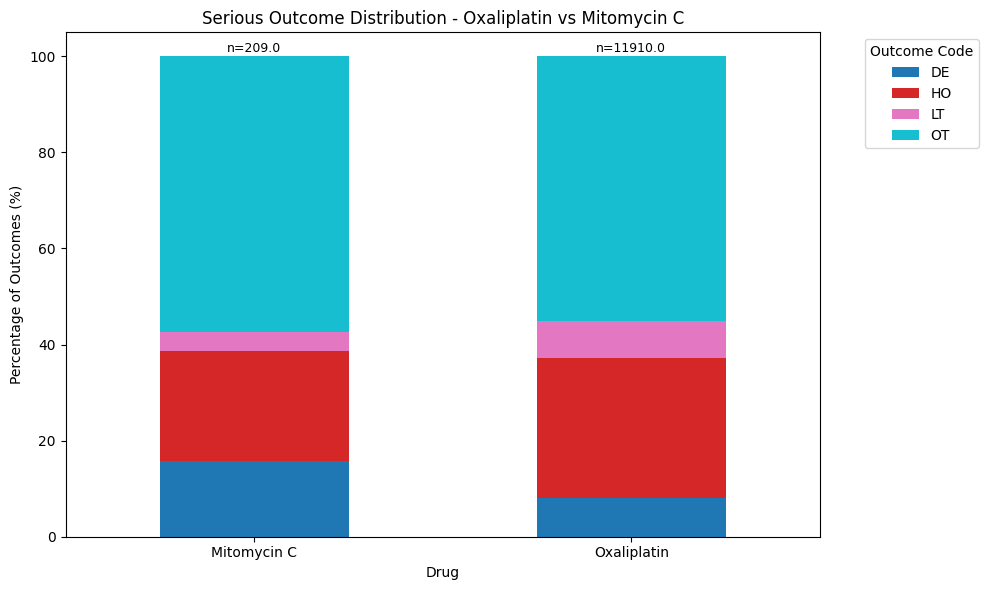

In [3]:
# Normalized stacked bar comparing outcome distributions for both drugs
oxa_outcomes['drug'] = 'Oxaliplatin'
mmc_outcomes['drug'] = 'Mitomycin C'

combined = pd.concat([oxa_outcomes, mmc_outcomes])
combined = combined[combined['outc_cod'].isin(['DE', 'HO', 'LT', 'OT'])]

pivot = combined.pivot_table(index='outc_cod', columns='drug', values='reports', fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=0), axis=1) * 100

pivot_pct.T.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab10')
plt.xlabel('Drug')
plt.ylabel('Percentage of Outcomes (%)')
plt.title('Serious Outcome Distribution - Oxaliplatin vs Mitomycin C')
plt.xticks(rotation=0)
plt.legend(title='Outcome Code', bbox_to_anchor=(1.05, 1), loc='upper left')

for i, drug in enumerate(pivot_pct.columns):
    total = pivot[drug].sum()
    plt.text(i, 101, f'n={total}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()